**Importing Libraries & Loading Dataset**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
# Set visualization style
sns.set(style="whitegrid")


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("/content/dirty_data1.csv")
df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,NaN,17.0,5.0,171.000000,1.0,1.0,NaN,1.0,19.0,12.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,10.8,15.05111,1.74,Dropout
1,1.0,15.0,1.0,NaN,1.0,1.0,160.0,1.0,1.0,3.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.30000,0.79,Graduate
2,1.0,1.0,5.0,28963.882389,1.0,1.0,122.0,NaN,37.0,37.0,...,0.0,6.0,0.0,0.0,NaN,0.0,10.8,1.40000,1.74,Dropout
3,NaN,17.0,2.0,9773.000000,1.0,1.0,122.0,1.0,38.0,37.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,NaN,15.05111,-3.12,Graduate
4,2.0,39.0,1.0,8014.000000,0.0,1.0,100.0,1.0,37.0,38.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.30000,0.79,Graduate


In [ ]:
df.shape


(4866, 37)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4866 entries, 0 to 4865
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4364 non-null   float64
 1   Application mode                                4405 non-null   float64
 2   Application order                               4391 non-null   float64
 3   Course                                          4449 non-null   float64
 4   Daytime/evening attendance	                     4381 non-null   float64
 5   Previous qualification                          4402 non-null   float64
 6   Previous qualification (grade)                  4402 non-null   float64
 7   Nacionality                                     4403 non-null   float64
 8   Mother's qualification                          4390 non-null   float64
 9   Father's qualification                   

In [ ]:
df.rename(columns={'Target': 'Student_Status'}, inplace=True)



In [ ]:
# Statistical summary
df.describe(include='all')


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Student_Status
count,4364.000000,4405.000000,4391.000000,4449.000000,4381.000000,4402.000000,4402.000000,4403.000000,4390.000000,4371.000000,...,4442.000000,4382.000000,4435.000000,4386.000000,4406.000000,4382.000000,4388.000000,4398.000000,4401.000000,4439
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2102
mean,1.511440,28.165167,2.412460,9948.523517,1.061207,10.104497,139.834222,5.565185,27.841347,30.601640,...,1.553926,7.416235,10.210282,6.044967,13.064045,0.575779,12.988267,1.967033,1.222253,NaN
std,1.513620,43.351632,3.197782,4922.369714,0.756213,25.303760,32.347824,16.765375,38.493451,38.050641,...,4.656997,5.420542,9.705032,7.356387,12.759716,1.923883,6.518211,3.400149,5.609956,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,3.000000,3.000000,...,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9254.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.790000,NaN
75%,1.000000,39.000000,2.000000,9670.000000,1.000000,1.000000,141.000000,1.000000,37.000000,37.000000,...,0.000000,8.000000,11.000000,6.000000,13.625000,0.000000,13.900000,2.600000,1.790000,NaN


**DATA CLEANING**

In [ ]:
# Check duplicates
df.duplicated().sum()


np.int64(13)

In [ ]:
# Remove duplicates
df = df.drop_duplicates()


In [ ]:
# Confirm
df.duplicated().sum()


np.int64(0)

In [ ]:
df.isnull().sum()


,0
Marital status,500
Application mode,461
Application order,474
Course,416
Daytime/evening attendance\t,484
Previous qualification,463
Previous qualification (grade),464
Nacionality,463
Mother's qualification,476
Father's qualification,493


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-3902818140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [ ]:
#Remove Invalid / Impossible Values
grade_cols = [col for col in df.columns if 'grade' in col.lower()]

for col in grade_cols:
    df = df[df[col] >= 0]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


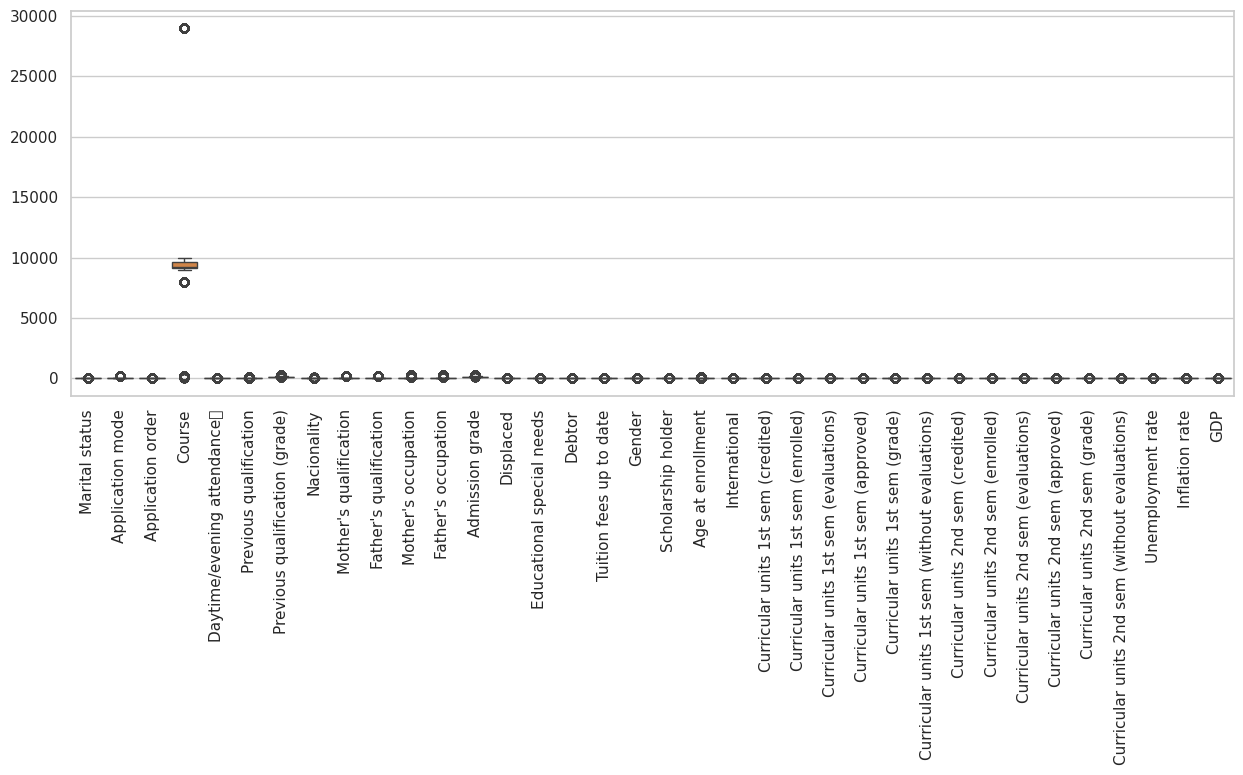

In [ ]:
#Detect & Treat Outliers (IQR Method)
plt.figure(figsize=(15,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()


In [ ]:
#Cap Outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)


In [ ]:
#Final Cleaning Check
df.shape


(4853, 37)

In [ ]:
df.isnull().sum()


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [ ]:
df.duplicated().sum()


np.int64(31)

**EDA**

In [ ]:
#Confirms dataset size and verifies cleaned data.
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4853, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Student_Status
0,1.0,17.0,3.5,8292.5,1.0,1.0,133.1,1.0,19.0,12.0,...,0.0,4.5,0.0,0.0,7.271429,0.0,10.8,6.05,1.74,Dropout
1,1.0,15.0,1.0,9254.0,1.0,1.0,159.5,1.0,1.0,3.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.30,0.79,Graduate
2,1.0,1.0,3.5,10496.5,1.0,1.0,122.0,1.0,37.0,37.0,...,0.0,6.0,0.0,0.0,12.333333,0.0,10.8,1.40,1.74,Dropout
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,11.1,6.05,-3.12,Graduate
4,1.0,39.0,1.0,8292.5,1.0,1.0,107.5,1.0,37.0,38.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.30,0.79,Graduate


In [ ]:
#dentify Numerical and Categorical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'C

In [ ]:
#Define Target Column
target_col = 'Student_Status'
print("Target Column:", target_col)


Target Column: Student_Status


In [ ]:
#Statistical Summary of Numerical Features
df[num_cols].describe()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4853.0,4853.000000,4853.000000,4853.000000,4853.0,4853.0,4853.000000,4853.0,4853.000000,4853.000000,...,4853.0,4853.0,4853.000000,4853.000000,4853.000000,4853.000000,4853.0,4853.000000,4853.000000,4853.000000
mean,1.0,22.247682,1.600659,9346.902535,1.0,1.0,134.033773,1.0,22.710694,25.104059,...,0.0,0.0,6.305378,8.391510,4.735627,12.008960,0.0,11.959860,1.474603,0.410471
std,0.0,23.357099,0.962035,482.208832,0.0,0.0,12.675458,0.0,20.696756,19.933176,...,0.0,0.0,1.189568,3.839476,2.921542,2.598426,0.0,3.148126,1.647447,2.598940
min,1.0,1.000000,0.000000,8292.500000,1.0,1.0,107.500000,1.0,1.000000,1.000000,...,0.0,0.0,4.500000,0.000000,0.000000,7.271429,0.0,7.600000,-0.800000,-4.060000
25%,1.0,1.000000,1.000000,9119.000000,1.0,1.0,127.000000,1.0,3.000000,4.000000,...,0.0,0.0,6.000000,6.000000,3.000000,11.000000,0.0,9.400000,0.300000,-1.700000
50%,1.0,17.000000,1.000000,9254.000000,1.0,1.0,133.100000,1.0,19.000000,19.500000,...,0.0,0.0,6.000000,8.000000,5.000000,12.333333,0.0,11.100000,1.400000,0.790000
75%,1.0,39.000000,2.000000,9670.000000,1.0,1.0,140.000000,1.0,37.000000,37.000000,...,0.0,0.0,7.000000,10.000000,6.000000,13.485714,0.0,13.900000,2.600000,1.790000
max,1.0,96.000000,3.500000,10496.500000,1.0,1.0,159.500000,1.0,88.000000,86.500000,...,0.0,0.0,8.500000,16.000000,10.500000,17.214286,0.0,20.650000,6.050000,7.025000


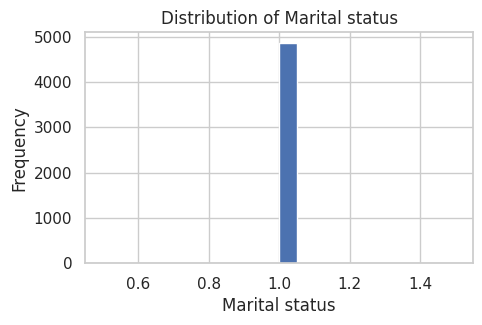

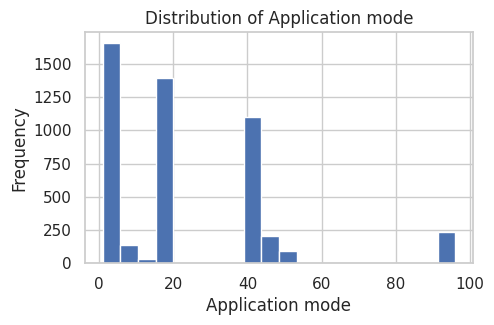

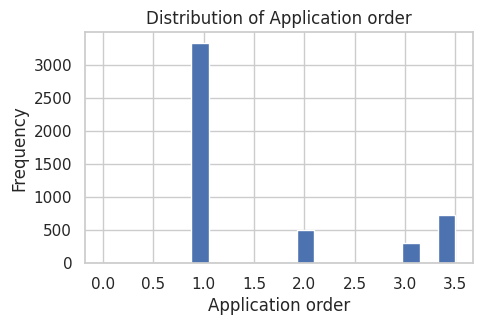

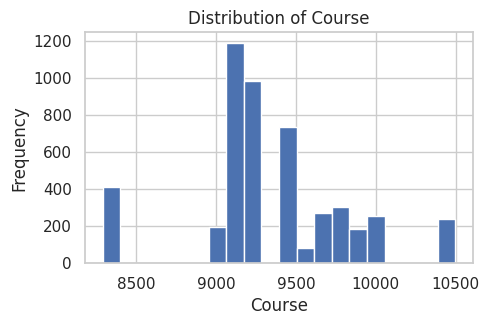

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


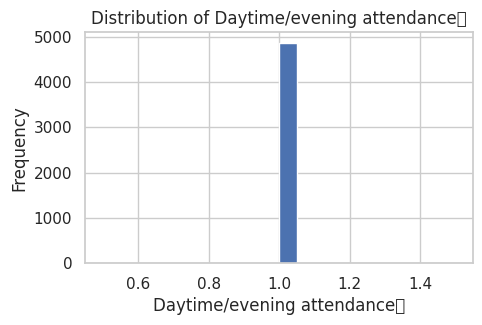

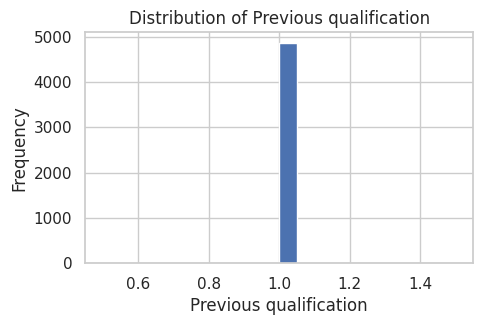

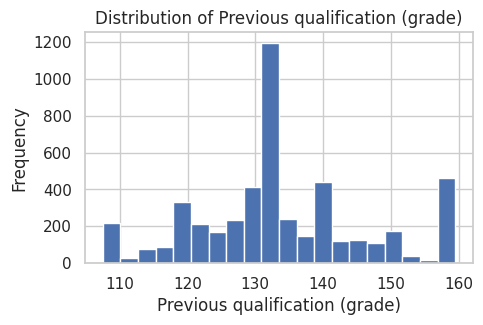

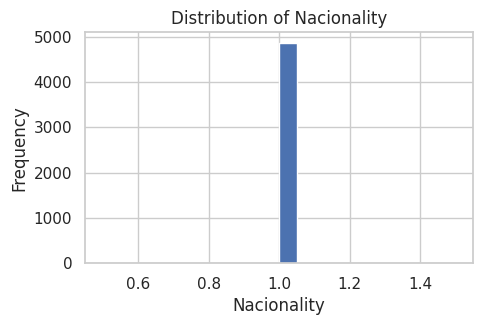

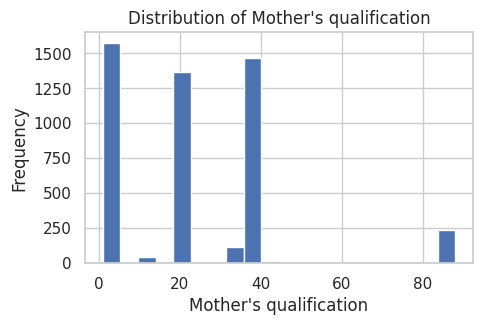

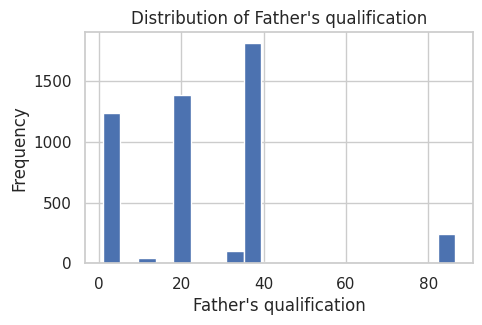

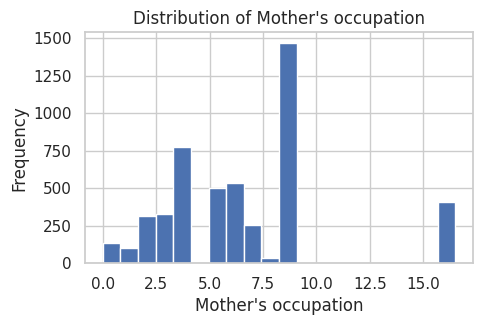

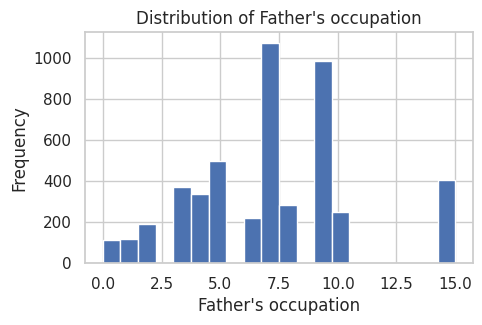

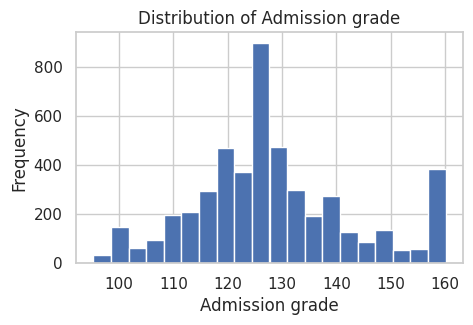

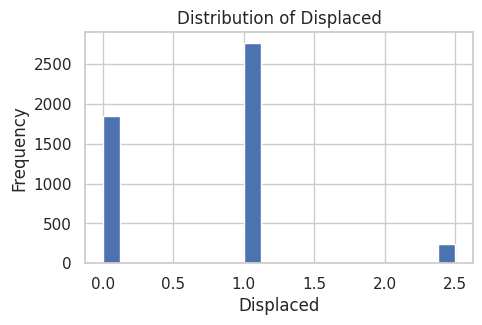

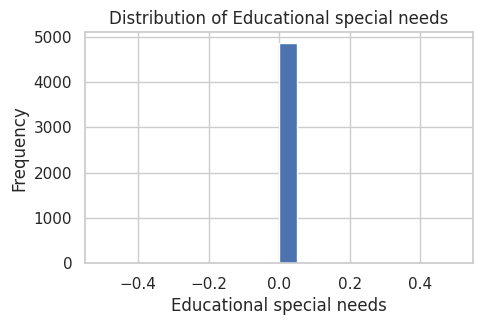

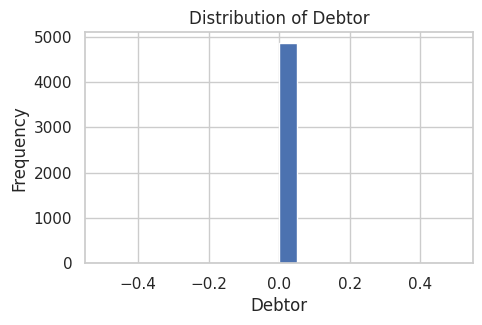

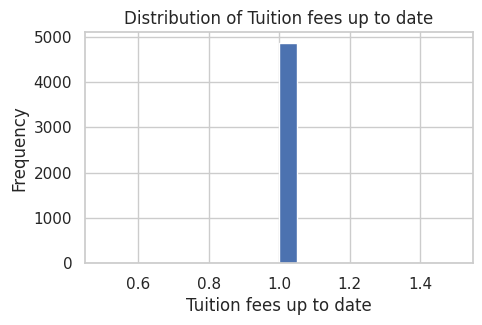

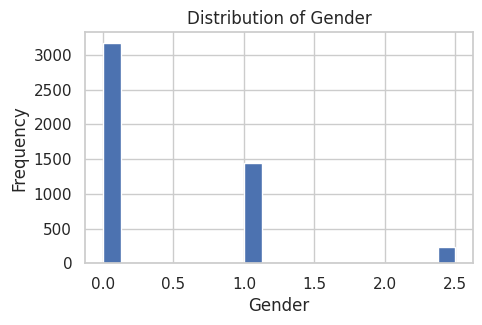

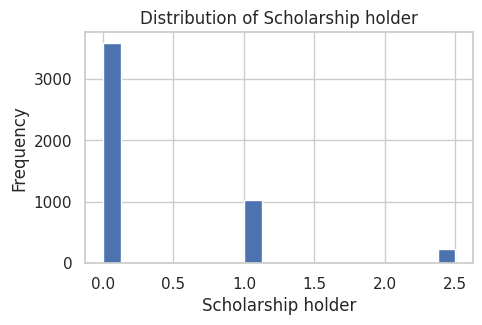

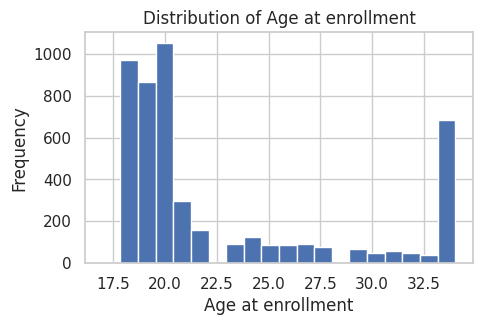

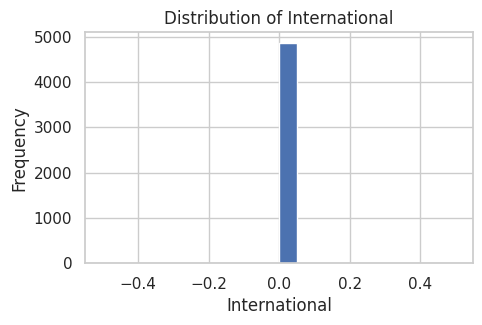

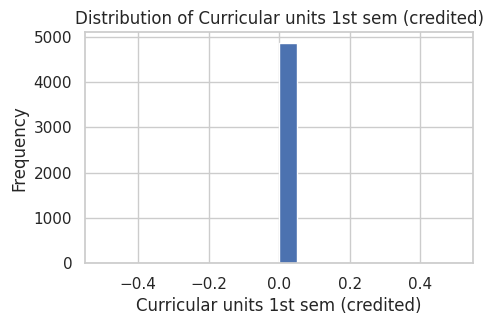

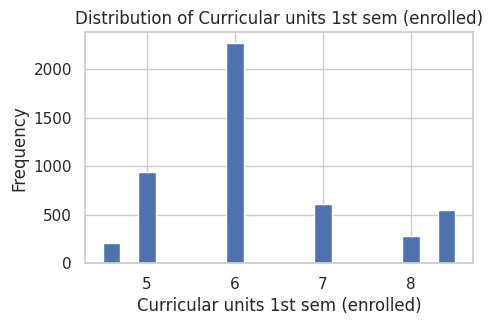

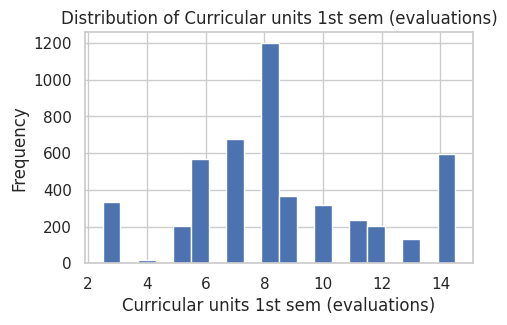

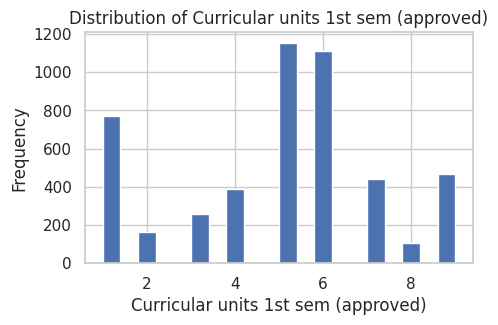

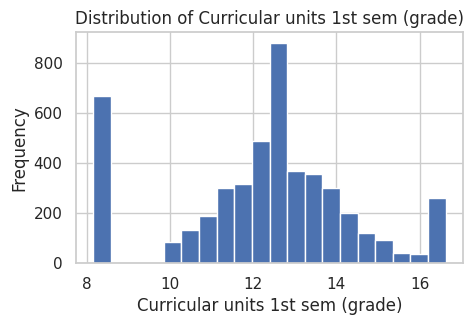

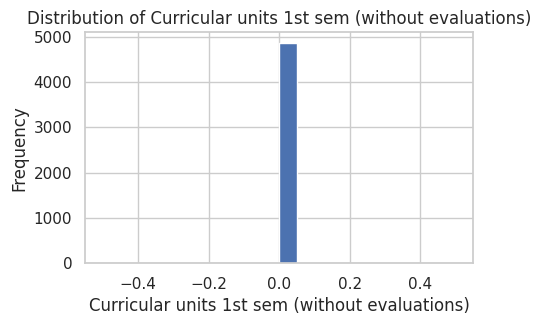

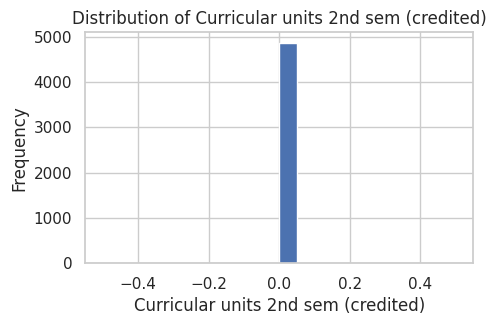

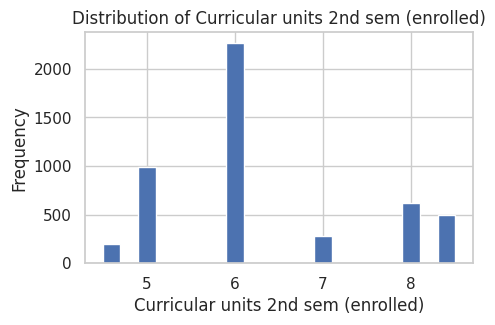

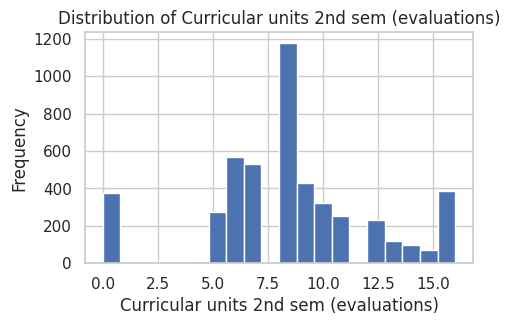

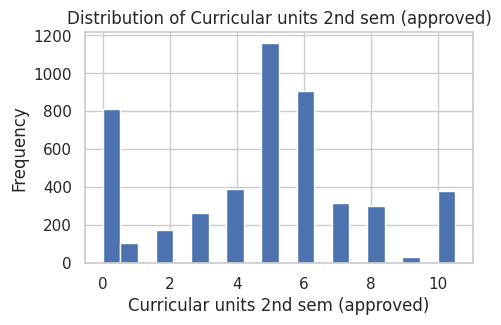

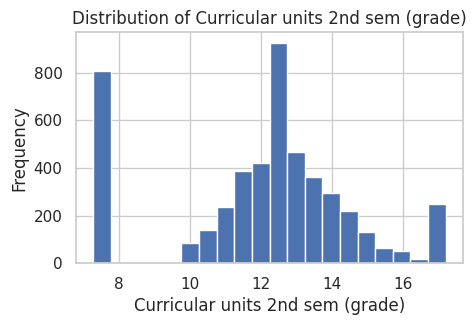

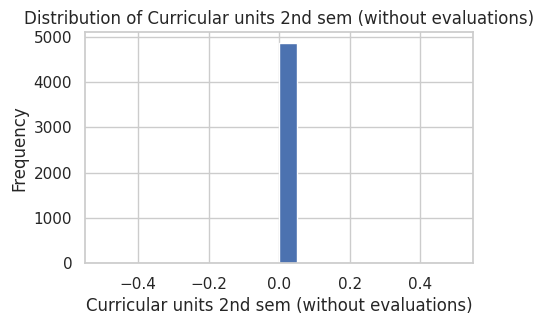

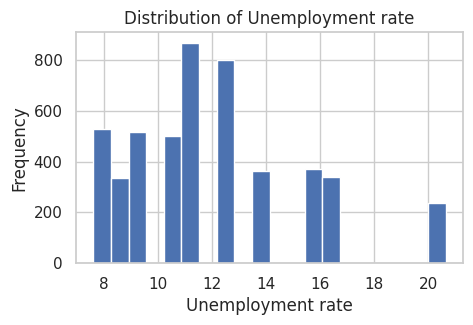

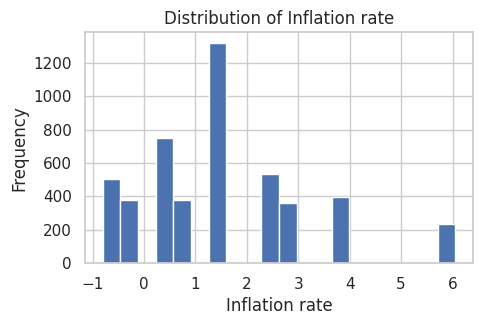

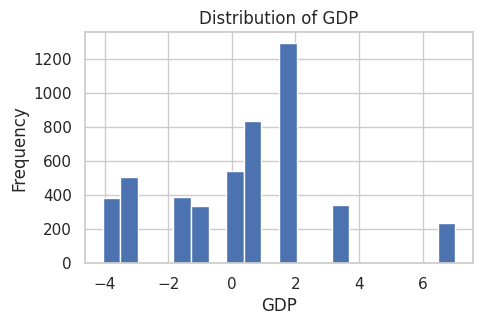

In [ ]:
#Distribution of Numerical Features
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


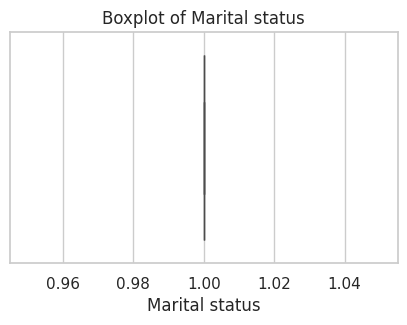

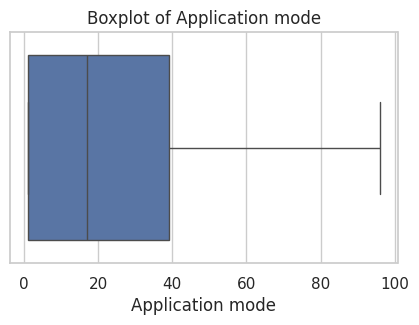

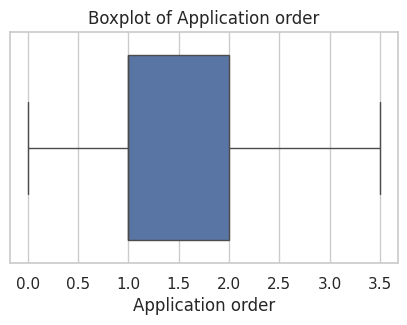

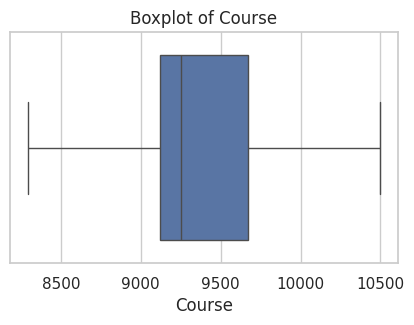

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


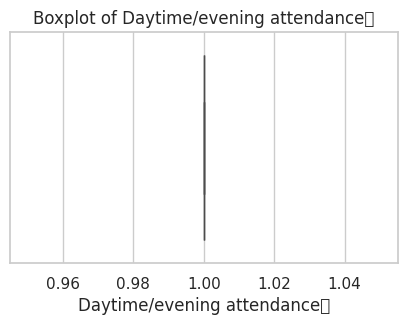

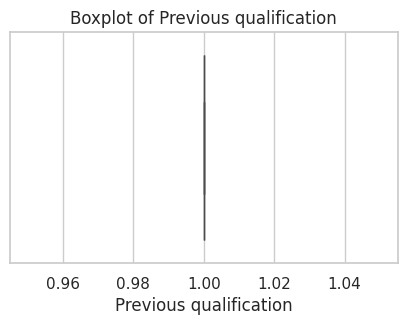

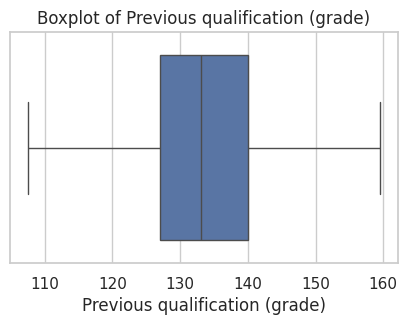

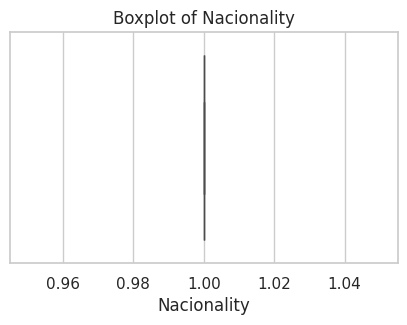

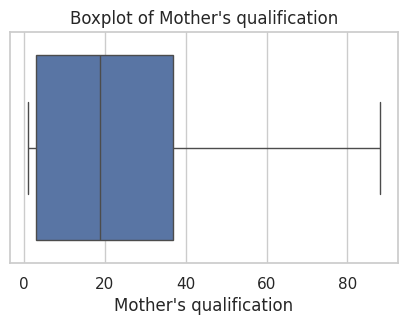

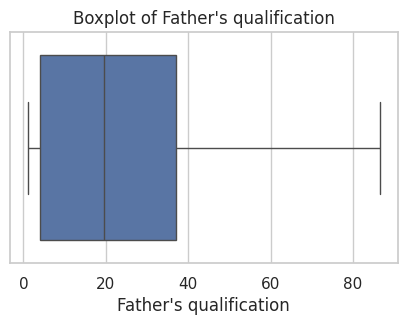

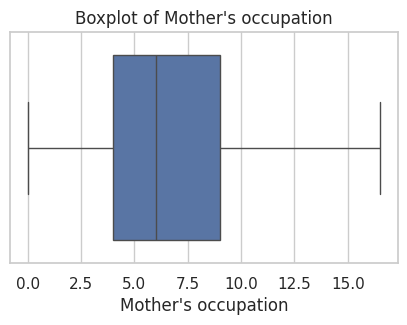

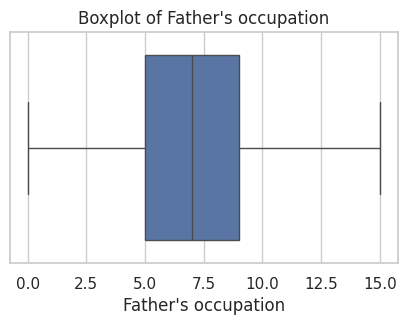

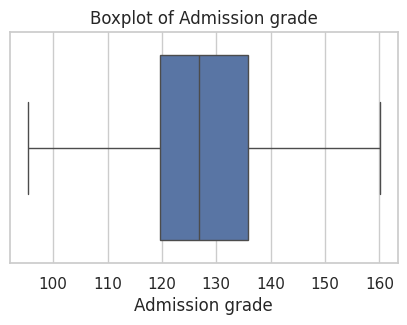

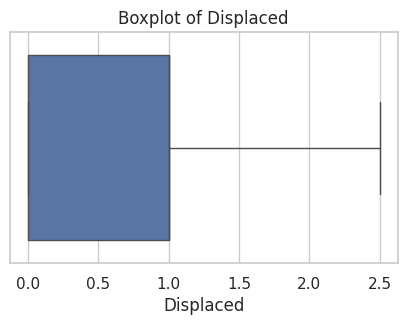

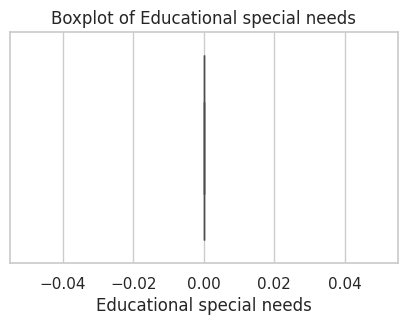

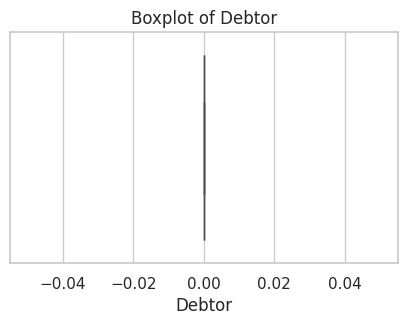

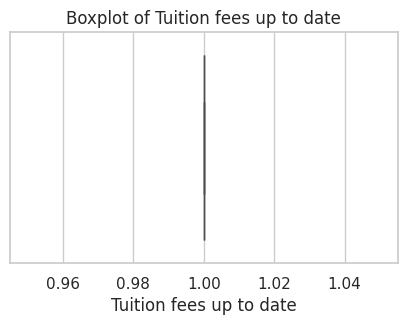

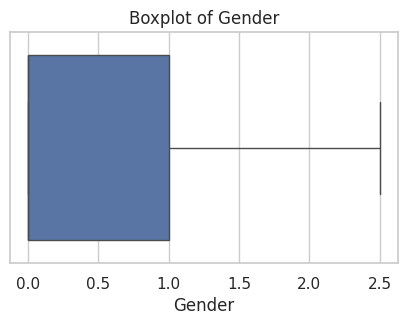

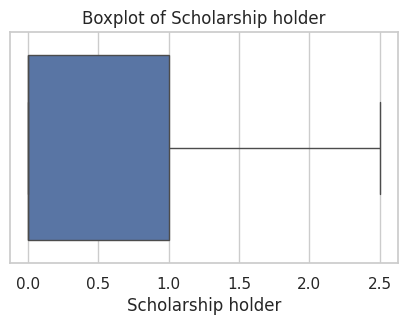

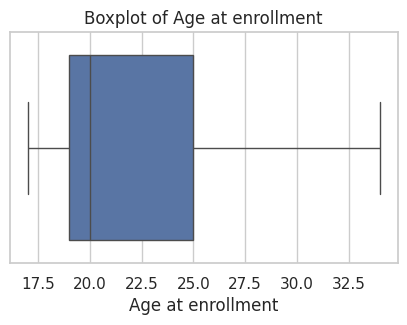

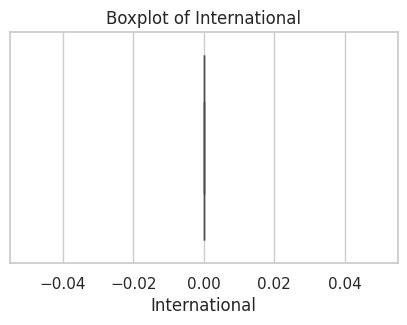

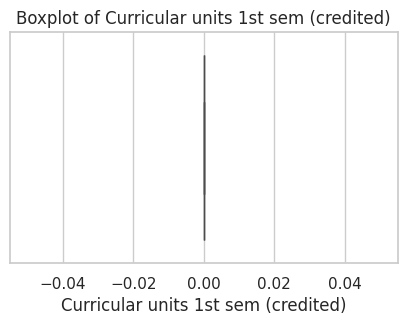

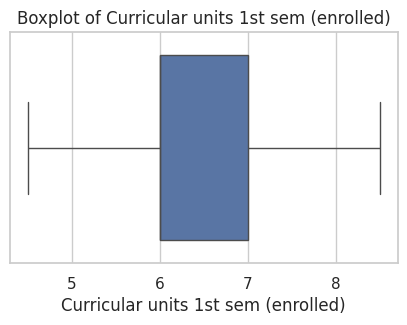

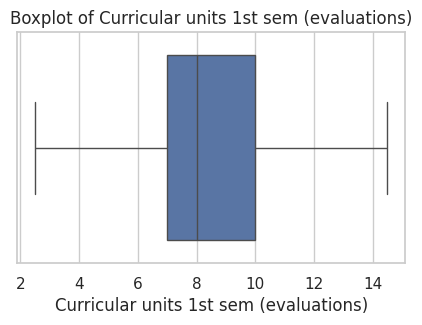

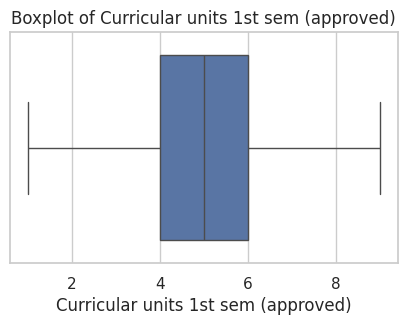

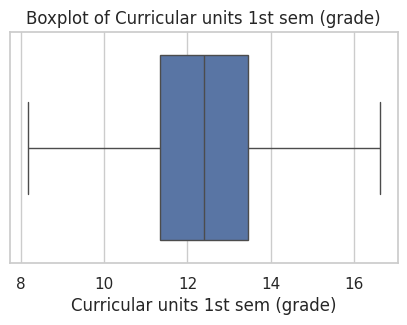

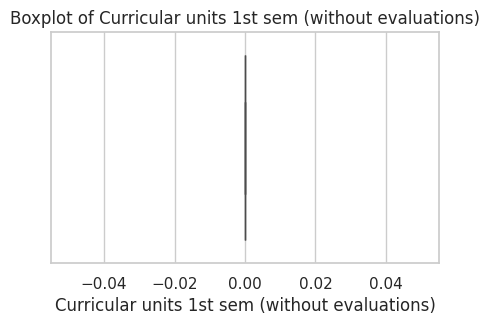

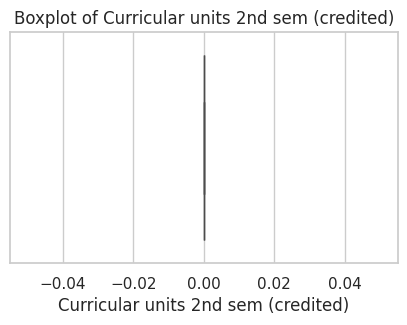

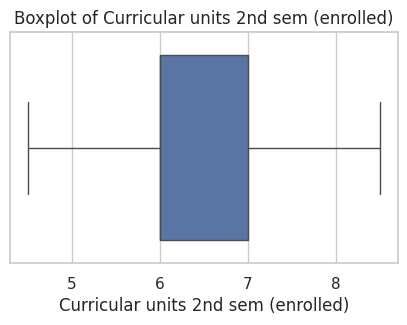

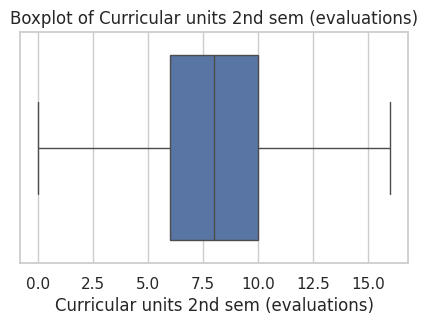

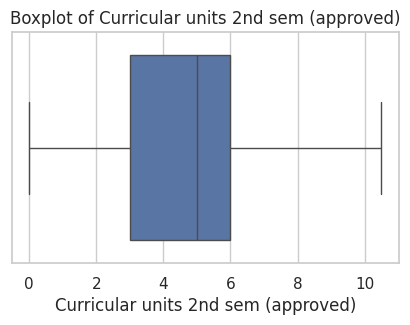

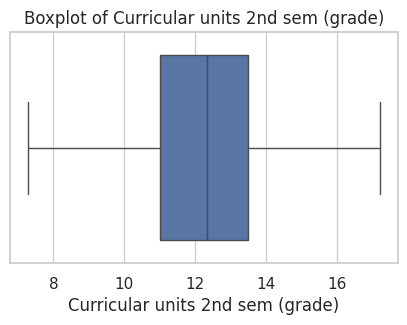

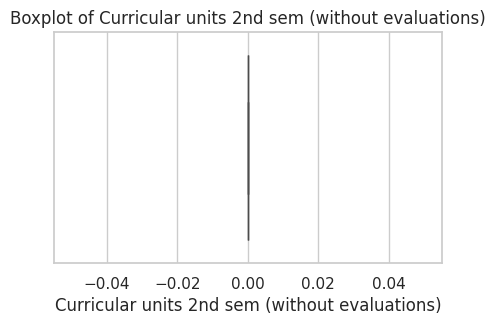

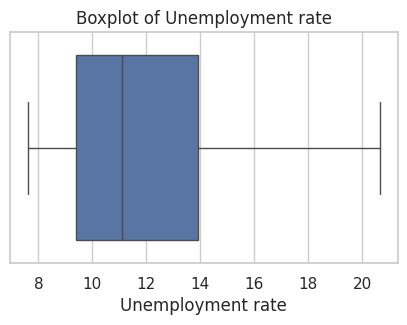

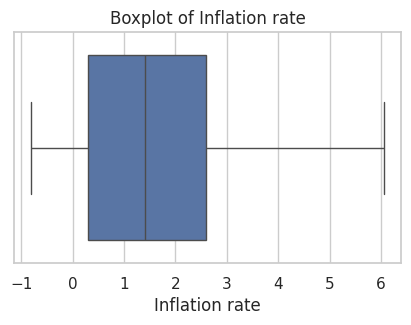

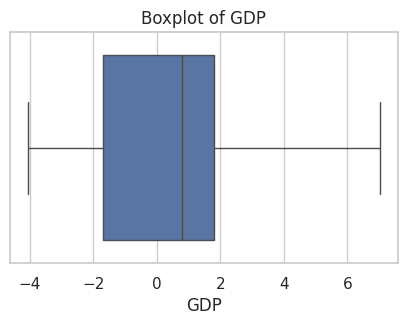

In [ ]:

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


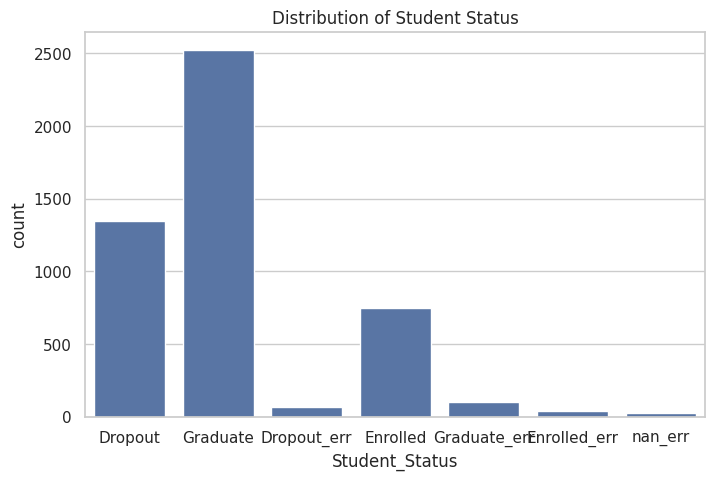

In [ ]:
# Check target variable distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Student_Status', data=df) # Corrected column name to 'Student_Status'
plt.title('Distribution of Student Status')
plt.show()

In [ ]:
# Check class balance
print(df['Student_Status'].value_counts())
print(f"\nDropout Rate: {(df['Student_Status']=='Dropout').sum()/len(df)*100:.2f}%")

Student_Status
Graduate        2522
Dropout         1346
Enrolled         745
Graduate_err     104
Dropout_err       66
Enrolled_err      43
nan_err           27
Name: count, dtype: int64

Dropout Rate: 27.74%


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


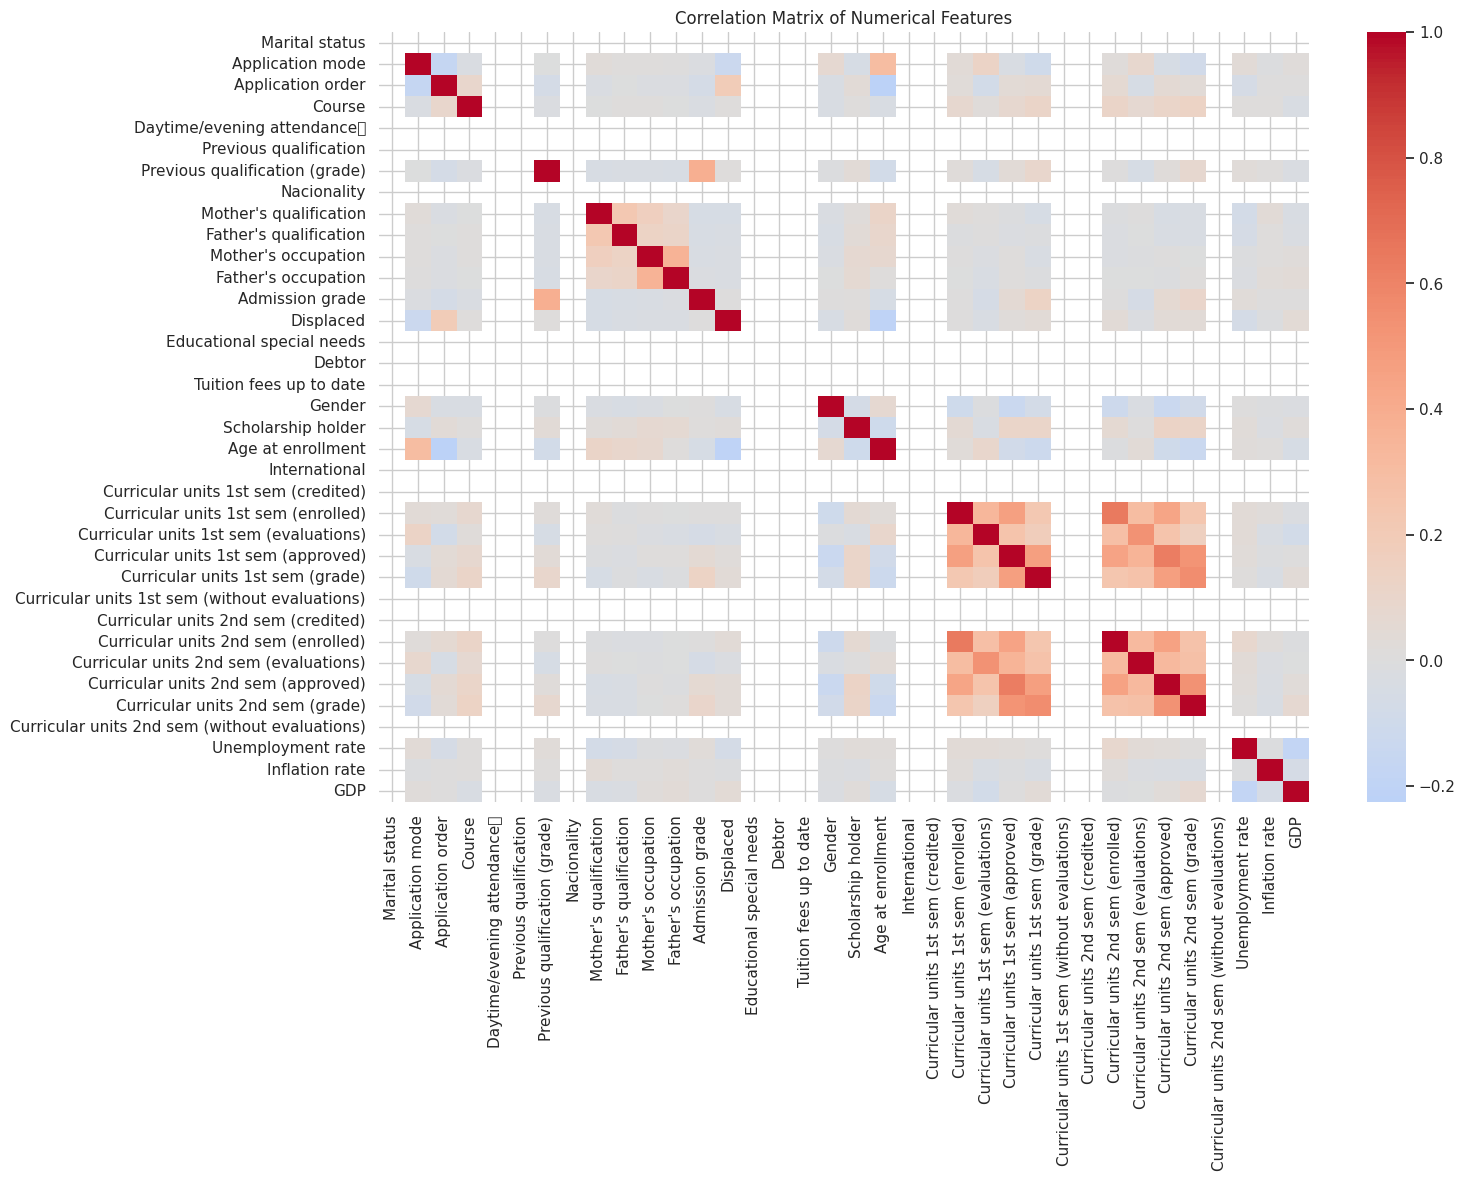

In [ ]:
# Correlation matrix for numerical features
plt.figure(figsize=(15,10))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

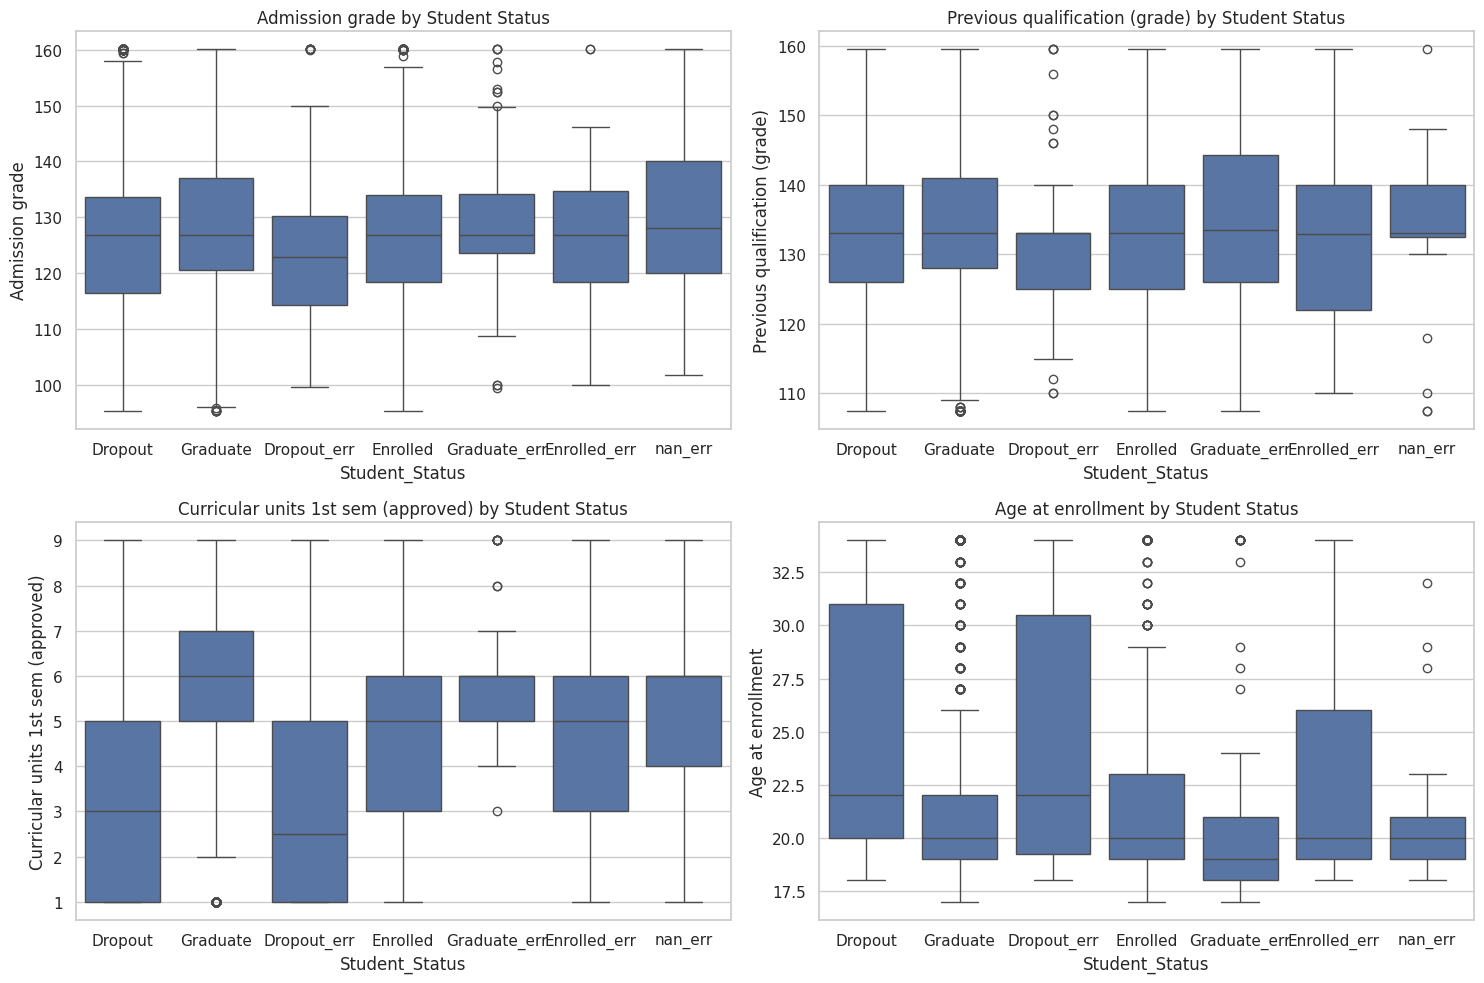

In [ ]:
# Compare key features by student status
key_features = ['Admission grade', 'Previous qualification (grade)',
                'Curricular units 1st sem (approved)', 'Age at enrollment']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for idx, feature in enumerate(key_features):
    row, col = idx // 2, idx % 2
    sns.boxplot(x='Student_Status', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Student Status')
plt.tight_layout()
plt.show()


**DATA PREPROCESSING**

In [ ]:
#Confirms final dataset size
#Ensures preprocessing did not remove excessive data
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4853, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Student_Status
0,1.0,17.0,3.5,8292.5,1.0,1.0,133.1,1.0,19.0,12.0,...,0.0,4.5,0.0,0.0,7.271429,0.0,10.8,6.05,1.74,Dropout
1,1.0,15.0,1.0,9254.0,1.0,1.0,159.5,1.0,1.0,3.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.30,0.79,Graduate
2,1.0,1.0,3.5,10496.5,1.0,1.0,122.0,1.0,37.0,37.0,...,0.0,6.0,0.0,0.0,12.333333,0.0,10.8,1.40,1.74,Dropout
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,11.1,6.05,-3.12,Graduate
4,1.0,39.0,1.0,8292.5,1.0,1.0,107.5,1.0,37.0,38.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.30,0.79,Graduate


In [ ]:
#Separate Numerical & Categorical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'C

In [ ]:
#Identify Target Variable

target_col = df.columns[-1]
print("Target Column:", target_col)

Target Column: Student_Status


In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])


In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [ ]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 4853 entries, 0 to 4865
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4853 non-null   float64
 1   Application mode                                4853 non-null   float64
 2   Application order                               4853 non-null   float64
 3   Course                                          4853 non-null   float64
 4   Daytime/evening attendance	                     4853 non-null   float64
 5   Previous qualification                          4853 non-null   float64
 6   Previous qualification (grade)                  4853 non-null   float64
 7   Nacionality                                     4853 non-null   float64
 8   Mother's qualification                          4853 non-null   float64
 9   Father's qualification                        

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Student_Status
0,1.0,17.0,3.5,8292.5,1.0,1.0,133.1,1.0,19.0,12.0,...,0.0,4.5,0.0,0.0,7.271429,0.0,10.8,6.05,1.74,0
1,1.0,15.0,1.0,9254.0,1.0,1.0,159.5,1.0,1.0,3.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.30,0.79,4
2,1.0,1.0,3.5,10496.5,1.0,1.0,122.0,1.0,37.0,37.0,...,0.0,6.0,0.0,0.0,12.333333,0.0,10.8,1.40,1.74,0
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,11.1,6.05,-3.12,4
4,1.0,39.0,1.0,8292.5,1.0,1.0,107.5,1.0,37.0,38.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.30,0.79,4


**FEATURE ENGINEERING**

In [ ]:
# Encode target variable
label_encoder = LabelEncoder()
df['student_status_encoded'] = label_encoder.fit_transform(df['Student_Status'])

In [ ]:
# Dropout = 0, Graduate = 1 (or vice versa, check mapping)
print("Target encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


Target encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6)}


In [ ]:
# Identify categorical columns that need encoding
# (Check which numerical columns are actually categorical)
categorical_columns = ['Marital status', 'Application mode', 'Previous qualification',
                       'Nacionality', 'Mother\'s qualification', 'Father\'s qualification',
                       'Gender', 'Scholarship holder', 'International']

In [ ]:
# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)


In [ ]:
# Feature scaling for numerical features (excluding target)
scaler = StandardScaler()
numerical_features = [col for col in num_cols if col not in ['student_status_encoded']]

In [ ]:
# Handle potential missing columns after encoding
existing_numerical = [col for col in numerical_features if col in df_encoded.columns]
df_encoded[existing_numerical] = scaler.fit_transform(df_encoded[existing_numerical])

** MODEL BUILDING**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier



In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier()
}

In [ ]:
# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")


Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...

Training SVM...

Training KNN...


In [ ]:
# Your 'Student_Status' is categorical, so encode it
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Student_Status'] = le.fit_transform(df['Student_Status'])

# Check what labels were created
print("Encoded classes:", le.classes_)
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded classes: [0 1 2 3 4 5 6]
Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6)}


In [ ]:
# Separate features (X) and target (y)
X = df.drop('Student_Status', axis=1)  # All columns except target
y = df['Student_Status']  # Target column


In [ ]:
# Check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4853, 37)
Target shape: (4853,)


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (3882, 37) (3882,)
Testing set: (971, 37) (971,)


In [ ]:
# Scale numerical features (if you have many numerical columns)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- Model 1: Logistic Regression ---
print("1. Training Logistic Regression...")
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"   Logistic Regression Accuracy: {accuracy_lr:.2%}")


1. Training Logistic Regression...
   Logistic Regression Accuracy: 95.67%


In [ ]:
# --- Model 2: Random Forest ---
print("\n2. Training Random Forest...")
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"   Random Forest Accuracy: {accuracy_rf:.2%}")



2. Training Random Forest...
   Random Forest Accuracy: 97.01%


In [ ]:
 #--- Model 3: Gradient Boosting ---
print("\n3. Training Gradient Boosting...")
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"   Gradient Boosting Accuracy: {accuracy_gb:.2%}")



3. Training Gradient Boosting...
   Gradient Boosting Accuracy: 100.00%


In [ ]:
from sklearn.model_selection import train_test_split

# Define target variable (y) and features (X)
y = df_encoded['Student_Status']
X = df_encoded.drop(columns=['Student_Status'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3882, 113)
X_test shape: (971, 113)
y_train shape: (3882,)
y_test shape: (971,)


In [ ]:
# Fit (train) the model
model.fit(X_train, y_train)

# Then make predictions
y_pred = model.predict(X_test)

In [ ]:
model = KNeighborsClassifier()

In [ ]:
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Store results
results[name] = {
  'model': model,
  'accuracy': accuracy,
  'precision': report['weighted avg']['precision'],
  'recall': report['weighted avg']['recall'],
  'f1_score': report['weighted avg']['f1-score'],
  'roc_auc': roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted') \
             if (y_pred_proba is not None and y_pred_proba.ndim == 2) else None
}

In [ ]:
    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {report['weighted avg']['precision']:.4f}")
    print(f"Recall: {report['weighted avg']['recall']:.4f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.4f}")
    if (y_pred_proba is not None and y_pred_proba.ndim == 2):
        print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted'):.4f}")
    else:
        print("ROC-AUC: Not applicable or could not be calculated (requires 2D y_pred_proba for multi-class)")

Accuracy: 0.9176
Precision: 0.8737
Recall: 0.9176
F1-Score: 0.8936
ROC-AUC: 0.9595


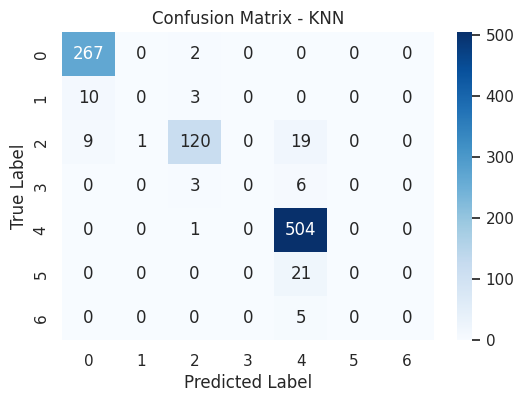

In [ ]:
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

M**ODEL COMPARISON**

In [ ]:
# Create comparison dataframe
results_df = pd.DataFrame(results).T
results_df = results_df[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']]
results_df = results_df.sort_values('accuracy', ascending=False)

<Figure size 1200x600 with 0 Axes>

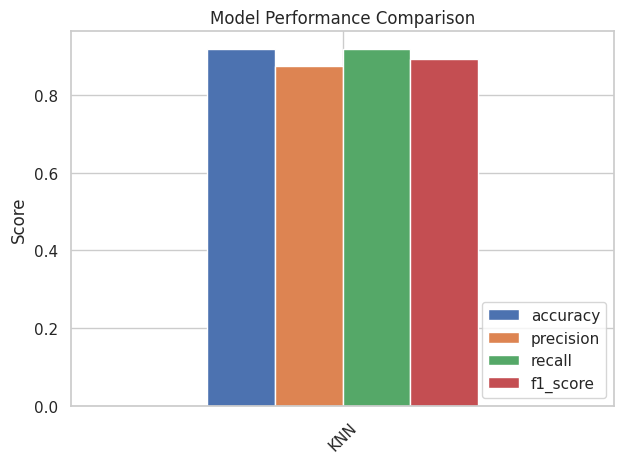

In [ ]:
# Visual comparison
plt.figure(figsize=(12, 6))
results_df[['accuracy', 'precision', 'recall', 'f1_score']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
#FEATURE IMPORTANCE (for tree-based models)
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']

    # Get feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

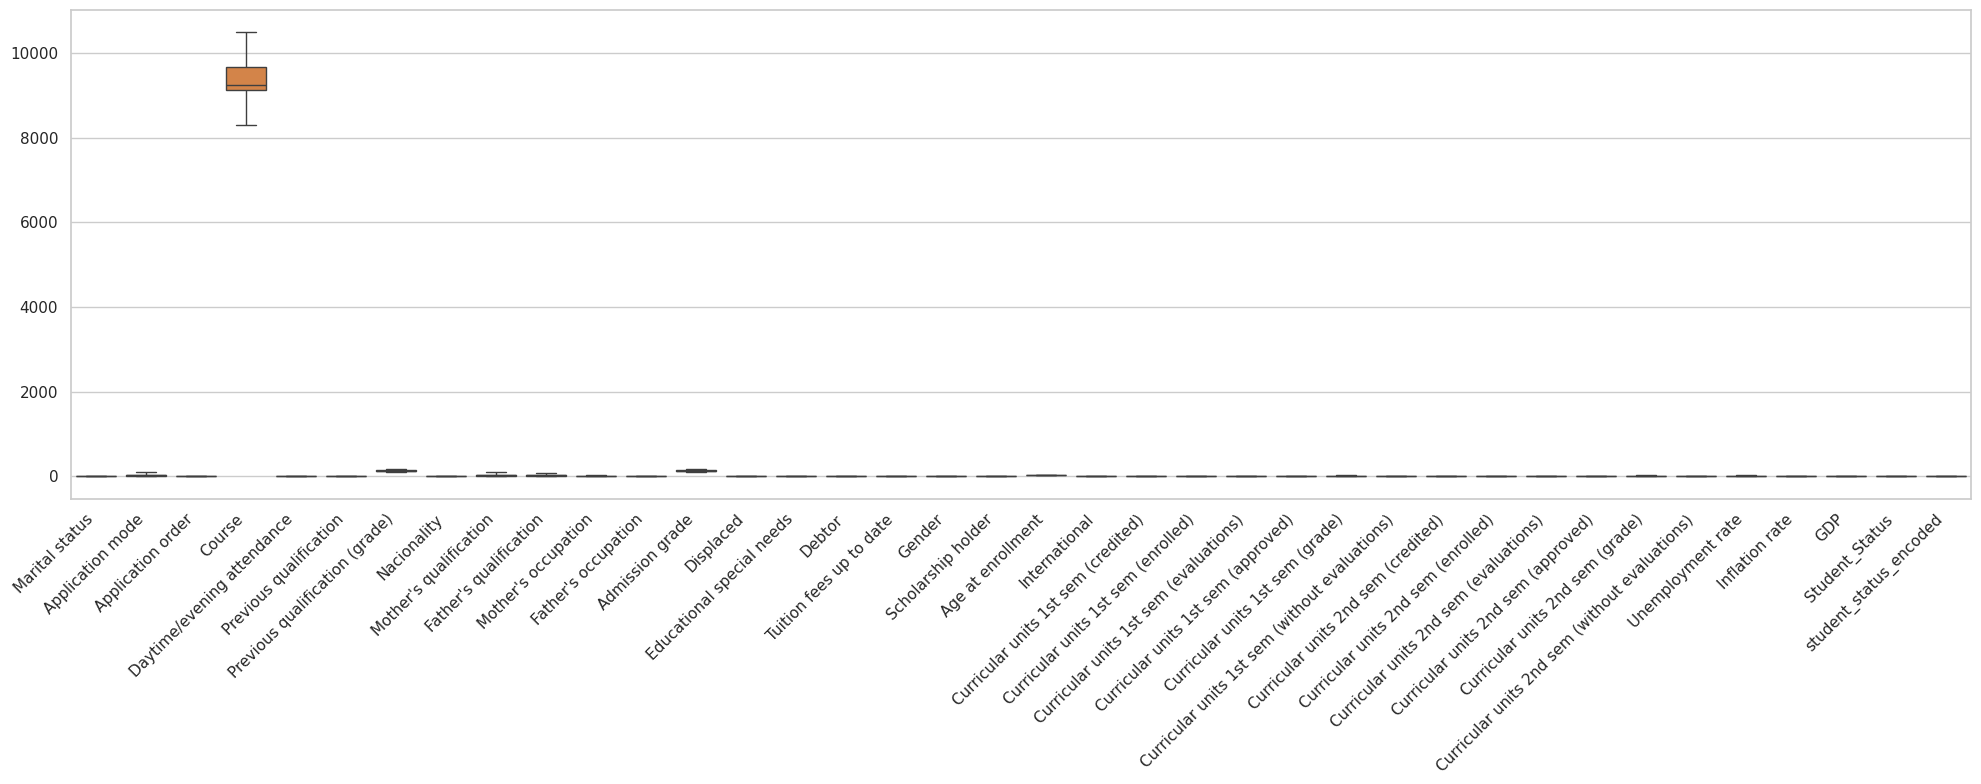

In [ ]:
# Clean column names
df.columns = df.columns.str.replace('\\t', '').str.strip()

# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create bigger boxplot
plt.figure(figsize=(20, 8))  # Bigger size: width=20, height=8
sns.boxplot(data=df[num_cols])

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()